In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Euler

In [2]:
S = [1_000]   # Number of susceptible individuals
I = [1]       # Number of infectious individuals
R = [0]       # Number of removed (and immune) or deceased individuals
N = [S[0] + I[0] + R[0]] 

# Parameters
beta = 1.4      # Infection rate
gamma = 0.1     # Recovery rate

# other
rng = np.random.default_rng(30)
iter_max = 10_000

dt = 0.01
for t in range(iter_max):
    # Get Parameters 
    St = S[t]
    It = I[t]
    Rt = R[t]
    Nt = N[t]

    # Calculate derevative
    dSt = -beta/Nt * It * St
    dIt = beta/Nt * It * St - gamma * It
    dRt = gamma * It

    # Update 
    S.append(St+dSt*dt)
    I.append(It+dIt*dt)
    R.append(Rt+dRt*dt)
    N.append(St+dSt*dt+It+dIt*dt+Rt+dRt*dt)



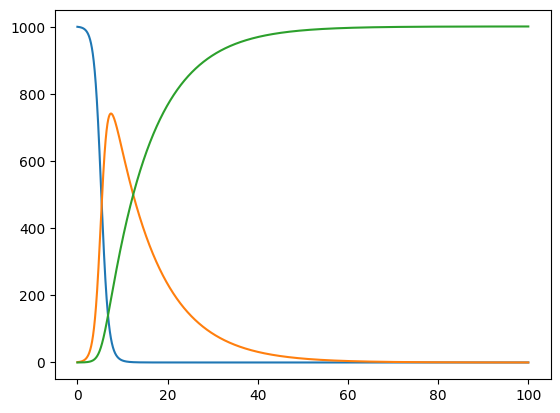

In [3]:
plt.plot(np.cumsum(dt*np.ones(10_001)),S)
plt.plot(np.cumsum(dt*np.ones(10_001)),I)
plt.plot(np.cumsum(dt*np.ones(10_001)),R)

# Simulation

In [4]:
S = [999]   # Number of susceptible individuals
I = [1]       # Number of infectious individuals
R = [0]       # Number of removed (and immune) or deceased individuals
N = [S[0] + I[0] + R[0]] 
T = [0]

# Parameters
beta = 1.4      # Infection rate
gamma = 0.1     # Recovery rate

# other
rng = np.random.default_rng(30)
max_iter = 10_000

iter = 0
while True:
    # Get Parameters 
    St = S[iter]
    It = I[iter]
    Rt = R[iter]
    Nt = N[iter] 
    t = T[iter]

    # Calculate rate of infection and rate of recovery
    a1 = beta * St * It / Nt    # Rate of infection
    a2 = gamma * It             # Rate of recovery
    a0 = a1 + a2

    # Determine next time step
    dt = rng.exponential(1/a0)

    u = rng.uniform(size=1)
    if u < a1/a0:
        Stp1 = St - 1
        Itp1 = It + 1
        Rtp1 = Rt
    else:
        Stp1 = St
        Itp1 = It - 1
        Rtp1 = Rt + 1
    
    # Append
    S.append(Stp1)
    I.append(Itp1)
    R.append(Rtp1)
    N.append(Stp1 + Itp1 + Rtp1)
    T.append(t+dt)

    if Itp1 == 0 or iter == max_iter:
        break
    
    iter += 1

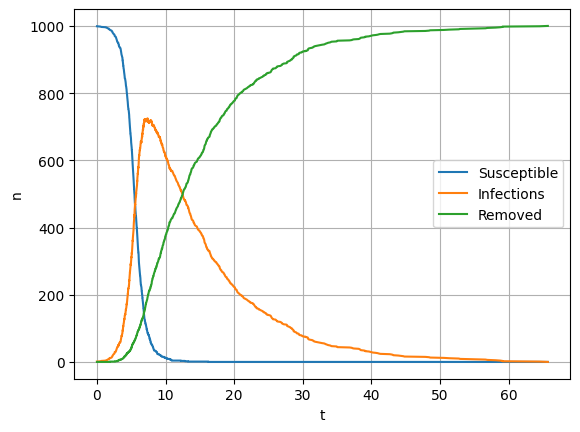

In [5]:
plt.plot(T,S, label="Susceptible")
plt.plot(T,I, label="Infections")
plt.plot(T, R, label="Removed")
plt.grid()
plt.xlabel("t")
plt.ylabel("n")
plt.legend()

# Grid

In [6]:
from scipy.signal import convolve2d

In [45]:
rng = np.random.default_rng(40)

# Intitial 
n = 100
max_iter = 1_00
S = [np.ones((n,n), dtype=np.int8)]
I = [np.zeros_like(S[0])]
R = [np.zeros_like(S[0])]

# Insert initial infected
n_start = 3
init = rng.integers(low=0,high=n, size=(2,n_start))
I[0][*init] = 1
S[0][*init] = 0

# Convolve kernel
kernel = np.ones((3,3))
kernel[1,1] = 0

# Parameters
beta = 0.7      # Infection rate
gamma = 0.01     # Recovery rate

for t in range(max_iter-1):
    # Previous state
    St = S[t]
    It = I[t]
    Rt = R[t]
    infected_neighbors = convolve2d(It,kernel, mode="same", boundary="fill", fillvalue=0)

    St_new = np.copy(St)
    It_new = np.copy(It)
    Rt_new = np.copy(Rt)

    for i in range(n):
        for j in range(n):
            # Find out if we should infect or not
            if (infected_neighbors[i,j] > 0) and (St[i,j] == 1):
                infect = rng.binomial(n=infected_neighbors[i,j], p=beta)
                if (np.sum(infect) > 0):
                    St_new[i,j] = 0
                    It_new[i,j] = 1
                
            # Find out if person becomes immune
            if (It[i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                if recover:
                    It_new[i,j] = 0
                    Rt_new[i,j] = 1
            

    # Append
    S.append(St_new)
    I.append(It_new)
    R.append(Rt_new)


In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib qt

# Define 3 distinct colors for values 0, 1, 2
colors = ['Blue', 'green', 'red']
cmap = mcolors.ListedColormap(colors)

fig, ax = plt.subplots()
img = ax.imshow(I[0] + 2*R[0], cmap=cmap, vmin=0, vmax=2)
cbar = fig.colorbar(img, ticks=[0, 1, 2])

for t in range(max_iter):
    im = I[t] + 2*R[t]
    img.set_data(im)
    plt.pause(0.1)